In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [3]:
df = pd.read_csv("/kaggle/input/titanic/train.csv")


In [4]:
df1 = df.copy()


# ***Visualisation***

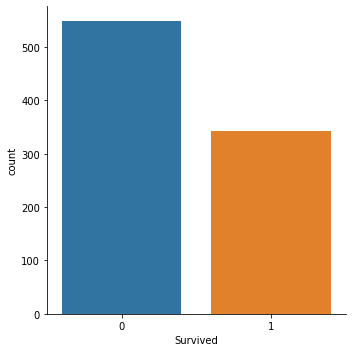

In [5]:
sns.catplot(x = "Survived", kind = "count", data = df1)


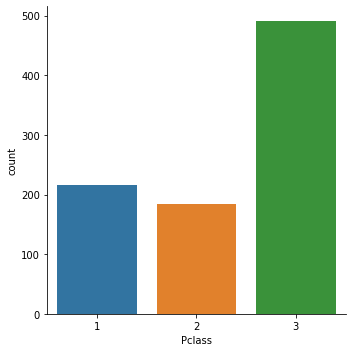

In [6]:
sns.catplot(x = "Pclass", kind = "count", data = df1)


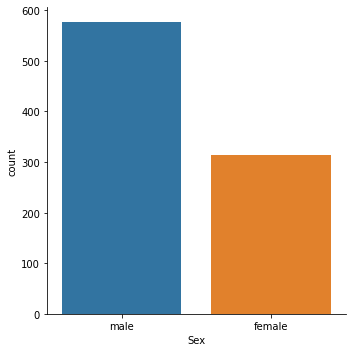

In [7]:
sns.catplot(x = "Sex", kind = "count", data = df1)


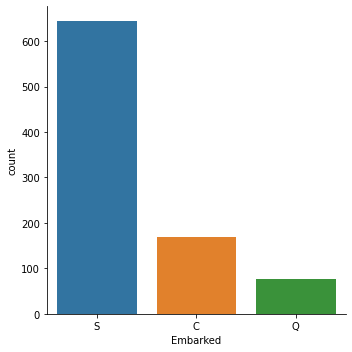

In [8]:
sns.catplot(x = "Embarked", kind = "count", data = df1)


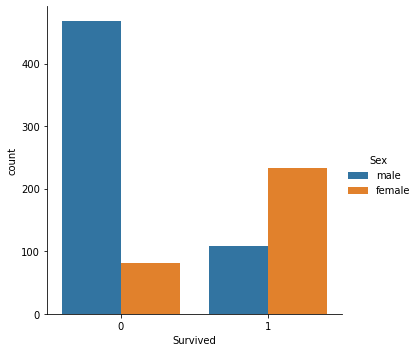

In [9]:
sns.catplot(x = "Survived", hue = "Sex", kind = "count", data = df1)


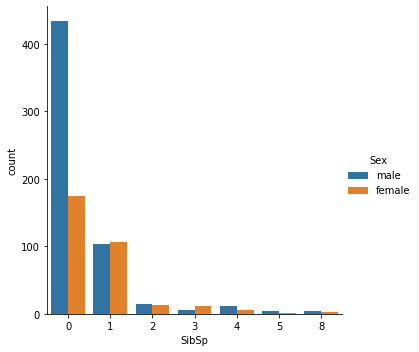

In [10]:
sns.catplot(x = "SibSp", hue = "Sex", kind = "count", data = df1)


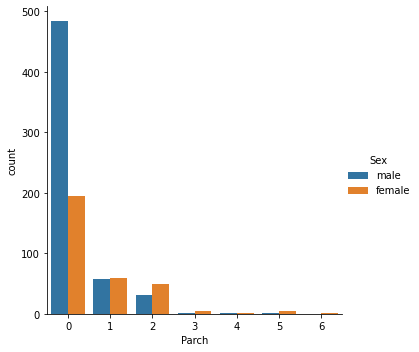

In [11]:
sns.catplot(x = "Parch", hue = "Sex", kind = "count", data = df1)


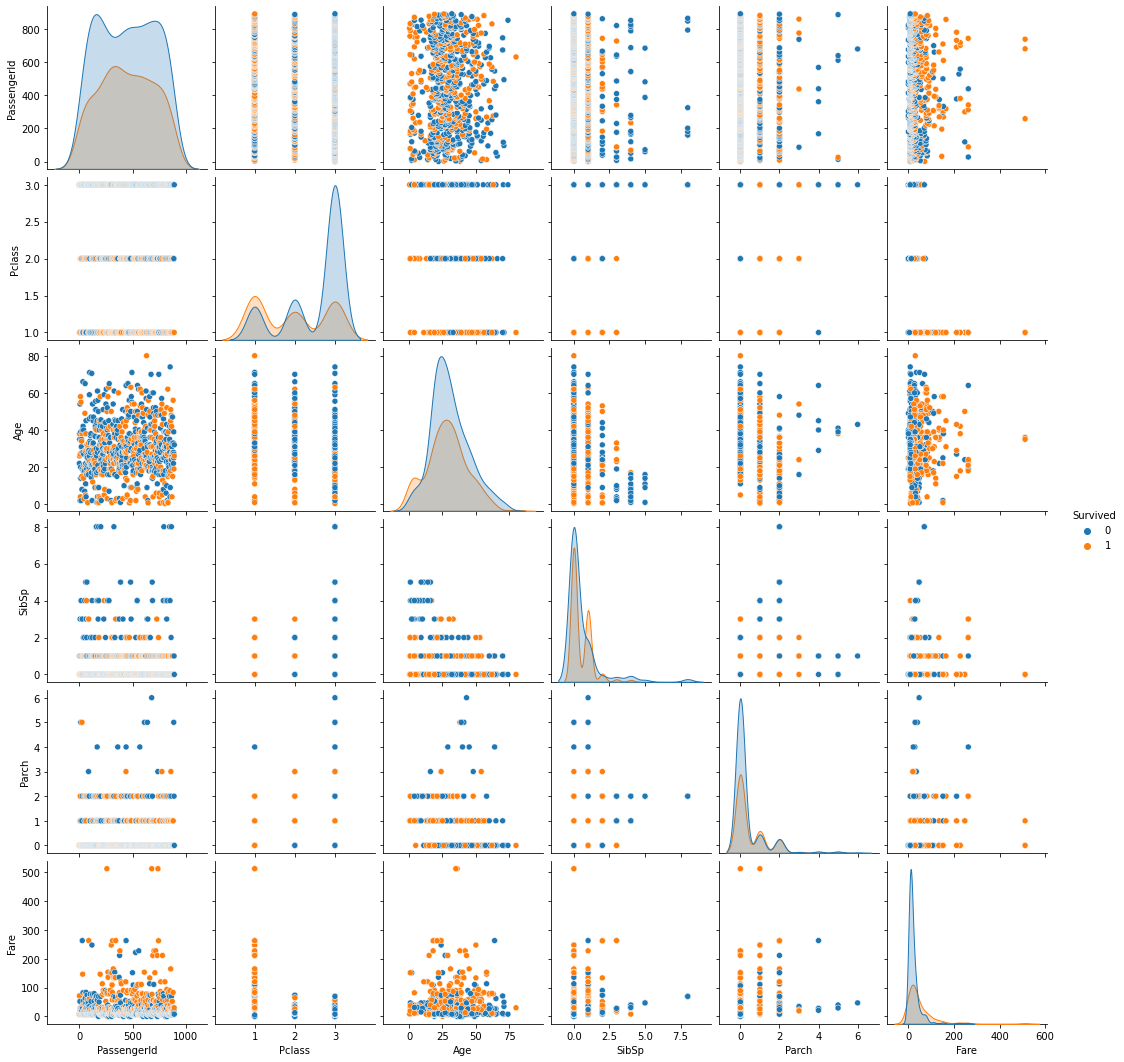

In [12]:
sns.pairplot(df1, hue = "Survived")


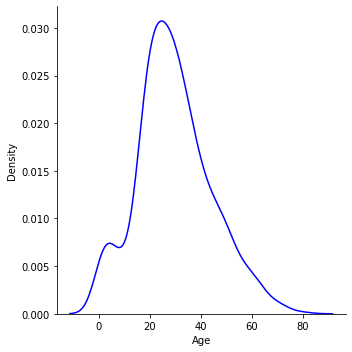

In [13]:
sns.displot(df1["Age"], kind = "kde", color = "blue")


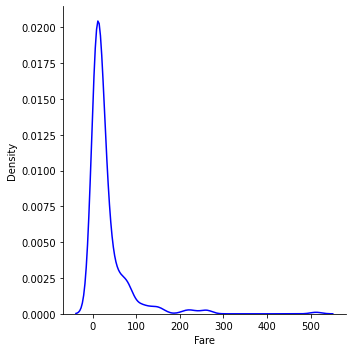

In [14]:
sns.displot(df1["Fare"], kind = "kde", color = "blue")


<AxesSubplot:xlabel='Age', ylabel='Density'>

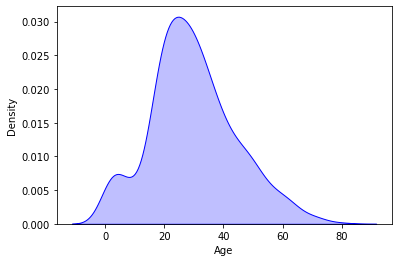

In [15]:
sns.kdeplot(df1["Age"], shade = True, color = "blue")


<AxesSubplot:xlabel='Fare', ylabel='Density'>

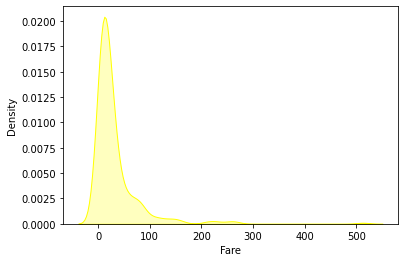

In [16]:
sns.kdeplot(df1["Fare"], shade = True, color = "yellow")


<AxesSubplot:xlabel='Age', ylabel='Fare'>

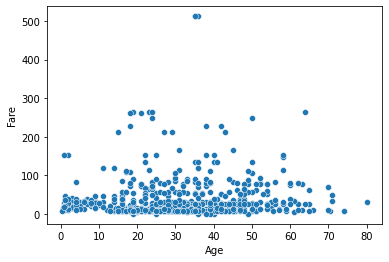

In [17]:
sns.scatterplot(x = "Age", y = "Fare", data = df1)


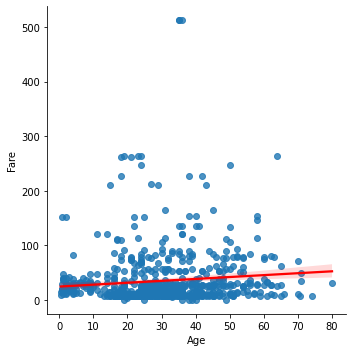

In [18]:
sns.lmplot(x = "Age", y = "Fare", data = df1, line_kws = {"color" : "red"})


<AxesSubplot:xlabel='Age'>

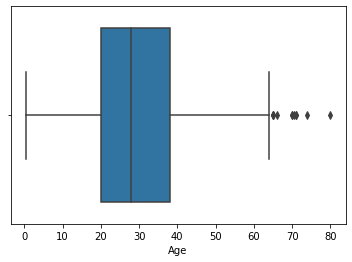

In [19]:
sns.boxplot(x = "Age", data = df1)


<AxesSubplot:xlabel='Fare'>

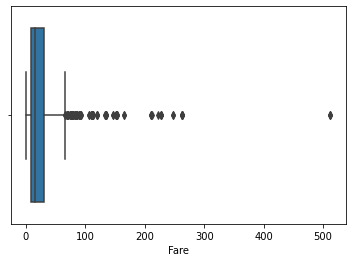

In [20]:
sns.boxplot(x = "Fare", data = df1)


<AxesSubplot:xlabel='Survived', ylabel='Fare'>

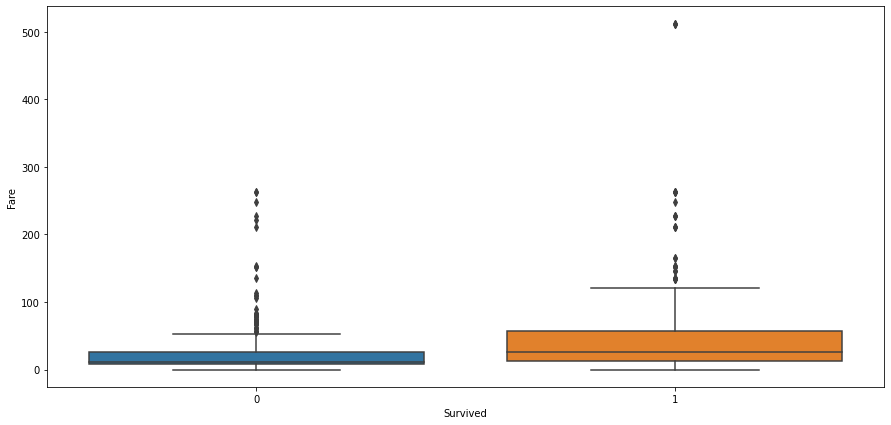

In [21]:
plt.figure(figsize = (15,7))
sns.boxplot(x = "Survived", y="Fare", data = df1)

<AxesSubplot:xlabel='Pclass', ylabel='Fare'>

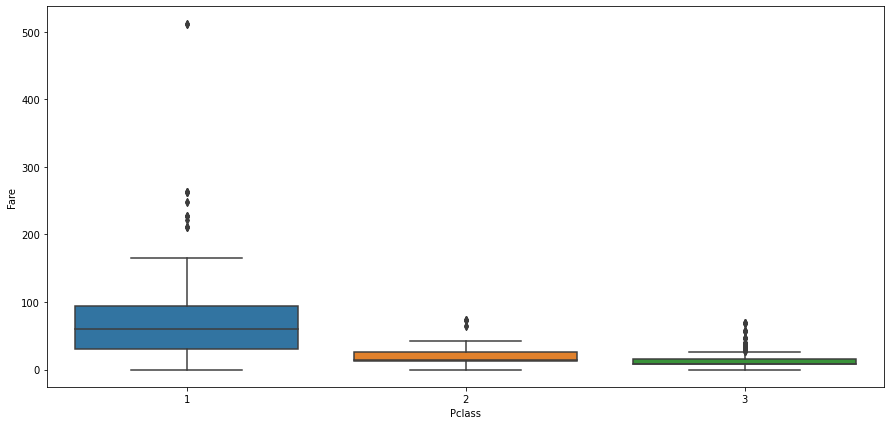

In [22]:
plt.figure(figsize = (15,7))
sns.boxplot(x = "Pclass", y="Fare", data = df1)

<Figure size 1080x504 with 0 Axes>

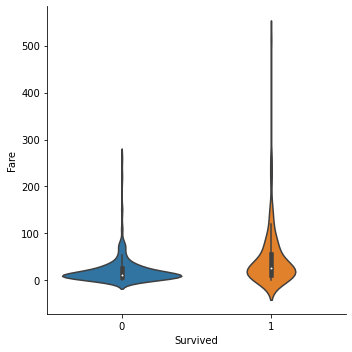

In [23]:
plt.figure(figsize = (15,7))
sns.catplot(x = "Survived", y="Fare", kind = "violin",data = df1)

<Figure size 1080x504 with 0 Axes>

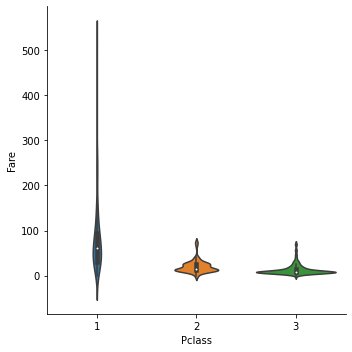

In [24]:
plt.figure(figsize = (15,7))
sns.catplot(x = "Pclass", y="Fare", kind = "violin",data = df1)

In [25]:
df1.groupby("Pclass")["Fare"].sum()

Pclass
1    18177.4125
2     3801.8417
3     6714.6951
Name: Fare, dtype: float64

In [26]:
fare_1= df1.groupby("Pclass",as_index = False)["Fare"].sum()
fare_1

,Pclass,Fare
0,1,18177.4125
1,2,3801.8417
2,3,6714.6951


In [27]:
fare_1.sort_values(by = "Fare",ascending = False, inplace = True)
fare_1

,Pclass,Fare
0,1,18177.4125
2,3,6714.6951
1,2,3801.8417


Text(0.5, 0.98, 'Pclass vs Fare')

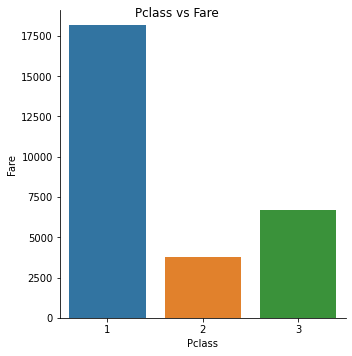

In [28]:
ax = sns.catplot(x = "Pclass", y = "Fare", kind = "bar", data = fare_1)
ax.fig.suptitle("Pclass vs Fare")

<AxesSubplot:xlabel='Pclass', ylabel='Fare'>

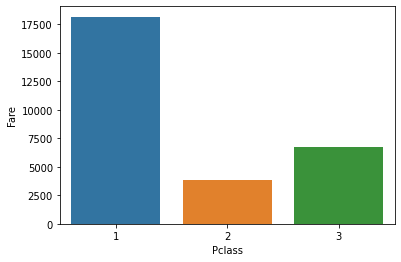

In [29]:
sns.barplot(x = "Pclass", y = "Fare", data = fare_1)

# ***MISSING VALUES***

-First of all, the percentage of missing data on the basis of variables is checked.

-Ways to deal with missing data :

-It can be deleted (not recommended if there is no structural defect and the percentage of missing values is not too high).

-Can be filled with value :

-Can be filled with 0.

-If variable is categorical it can be filled with mod.

-If the variable is numeric and not normally distributed, it can be filled with the median, if it is close to the normal distribution, it can be filled 
with the mean.

-Can be filled with ML-based filling techniques..

In [30]:
df1.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [31]:
df1.shape


(891, 12)

In [32]:
df1.dropna()
#missing values

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S
...,...,...,...,...,...,...,...,...,...,...,...,...
871,872,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",female,47.0,1,1,11751,52.5542,D35,S
872,873,0,1,"Carlsson, Mr. Frans Olof",male,33.0,0,0,695,5.0000,B51 B53 B55,S
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S


In [33]:
df1.dropna(subset=["Age"])


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='Age', ylabel='Density'>

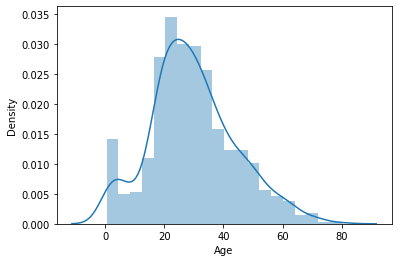

In [34]:
sns.distplot(df1["Age"])


In [35]:
df1["Age"].mean()


29.69911764705882

In [36]:
df1["Age"].median()


28.0

In [37]:
# filling missing values with the mean
df2 = df1["Age"].fillna(df["Age"].mean())


In [38]:
# filling missing values with the median
df2 = df1["Age"].fillna(df["Age"].median())

In [39]:
# filling missing values with the mode
df2 = df1["Embarked"].fillna(df1["Embarked"].mode()[0])

In [40]:
df2.isnull().sum()

0

# ***Visualisation of Missing Values***

<AxesSubplot:>

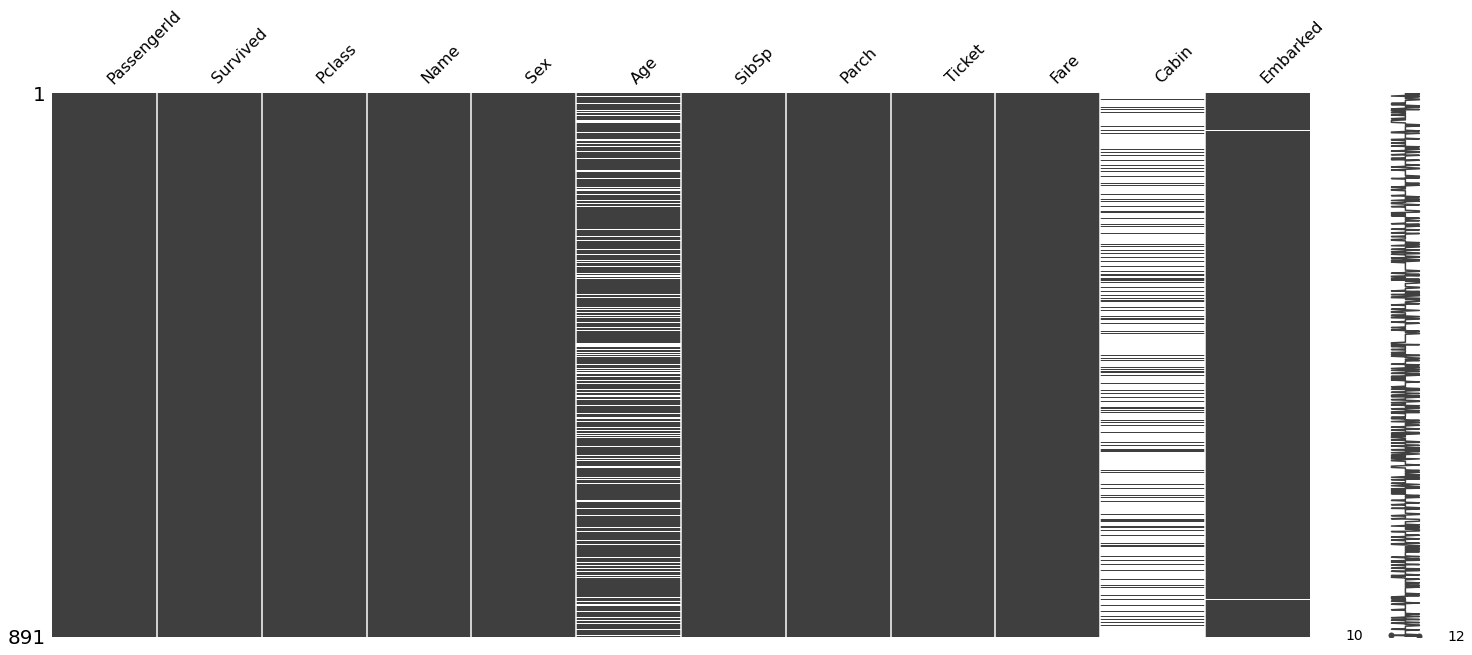

In [41]:
import missingno as msno
msno.matrix(df1)

# ***Thanks for your time. I hope you like it. Don't forget to vote if you like it.***